## Building an ANN

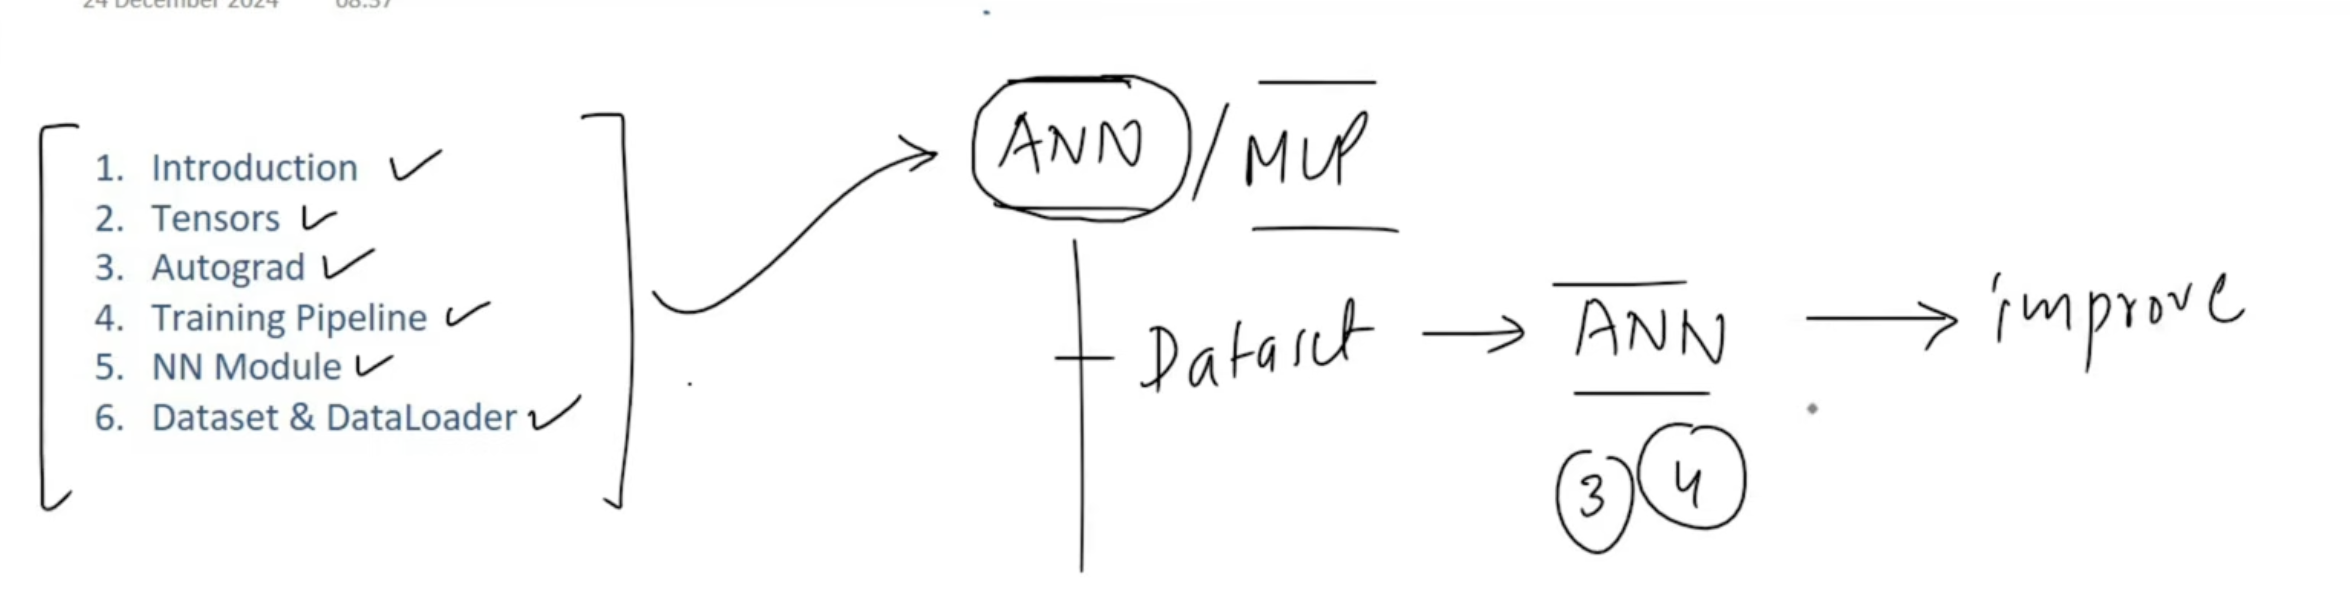

we will choose fashion MNIST dataset from kaggle


28 X 28 images with 70k rows 

70,000 images are a lot of data.we will draw a subset of 6000 images from 70k. We will build ANN on 6k images

## Architecture of ANN

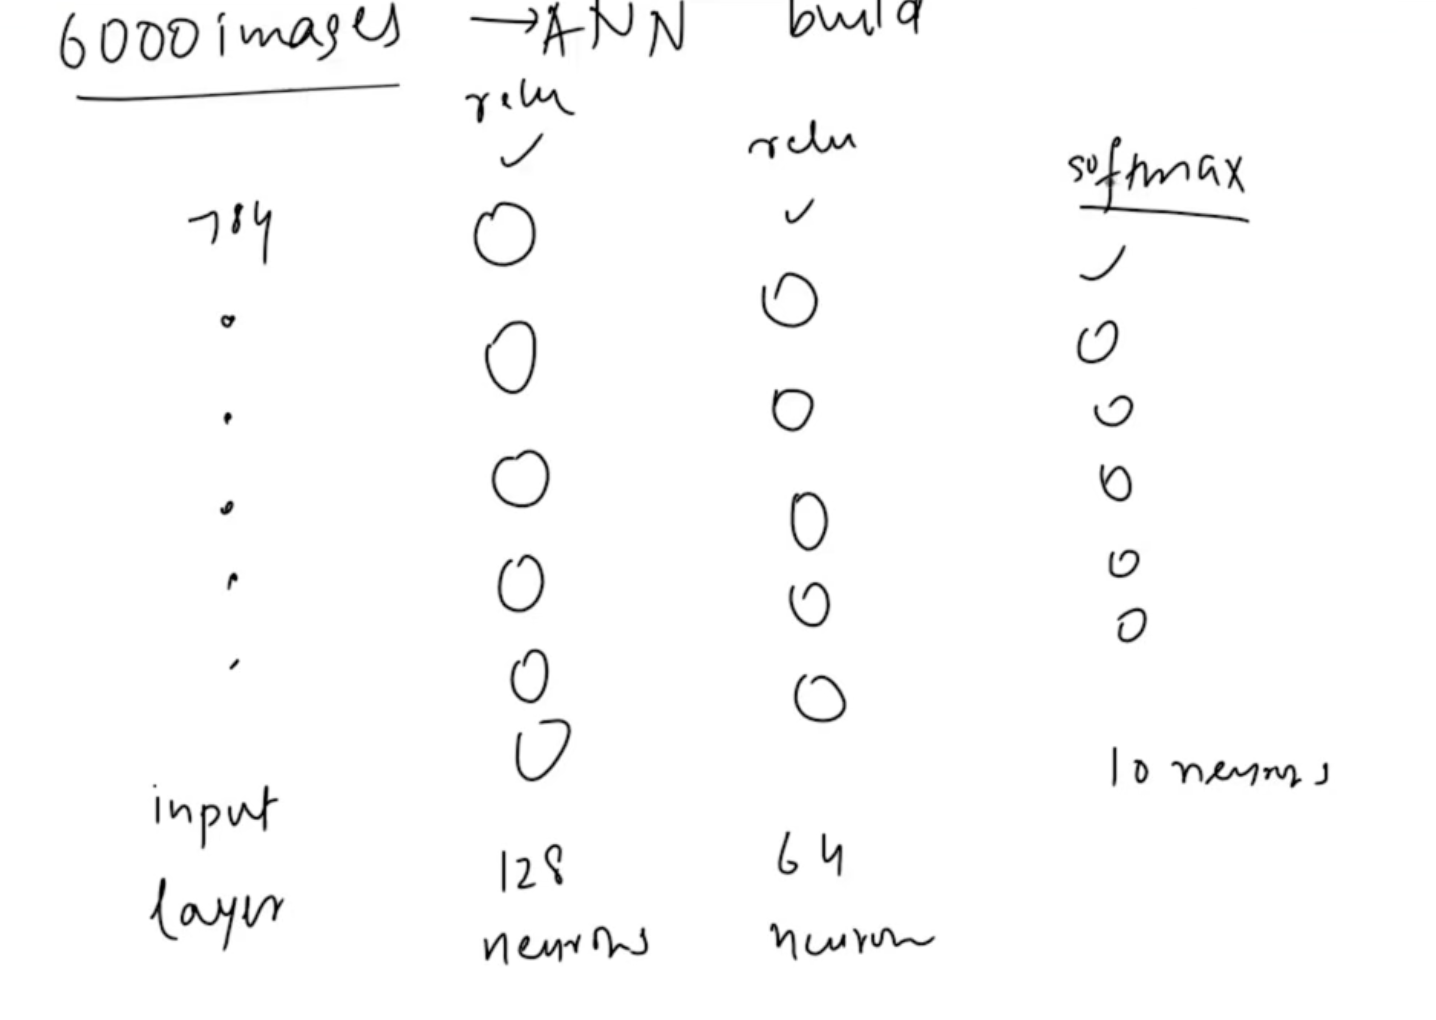

## Workflow

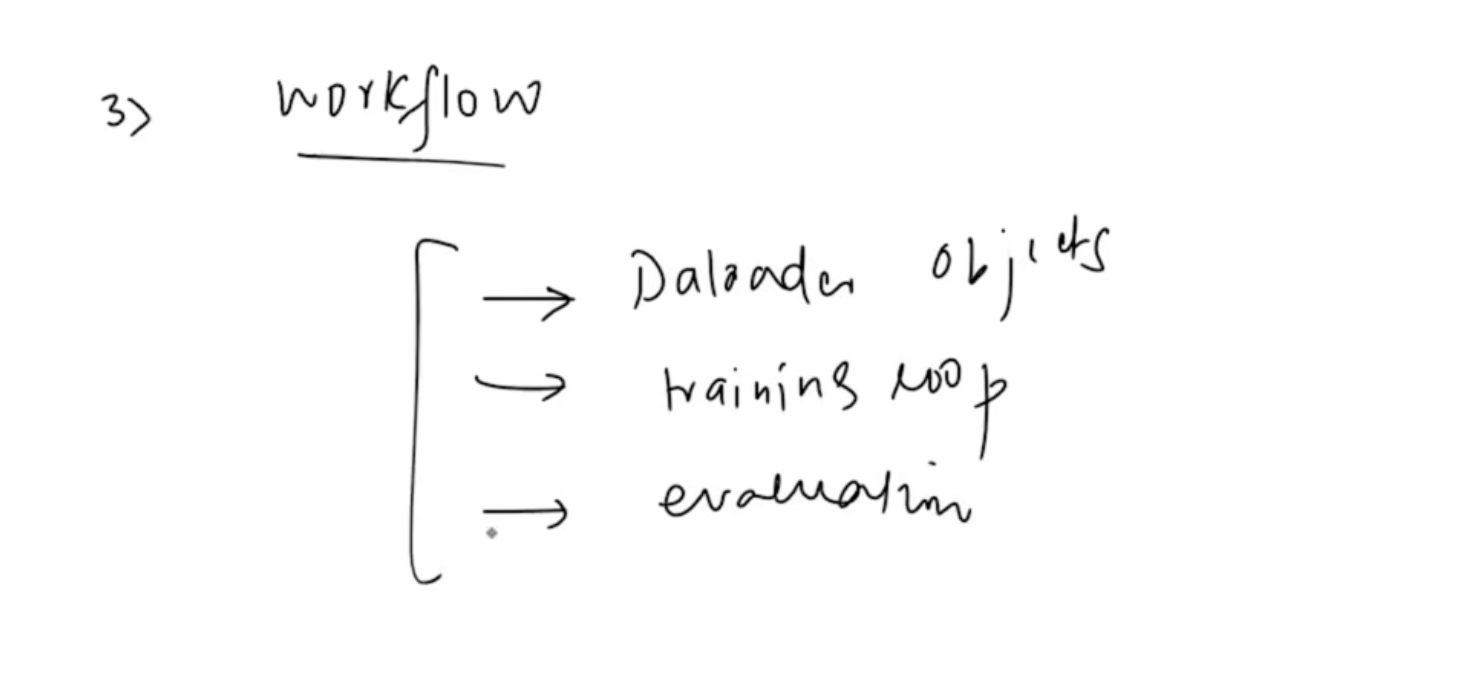

In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt 

In [2]:
## setting the seed for reproducibility
torch.manual_seed(42)

In [3]:
df=pd.read_csv('/Users/priyanshugupta/Desktop/Pytorch/Datasets/fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


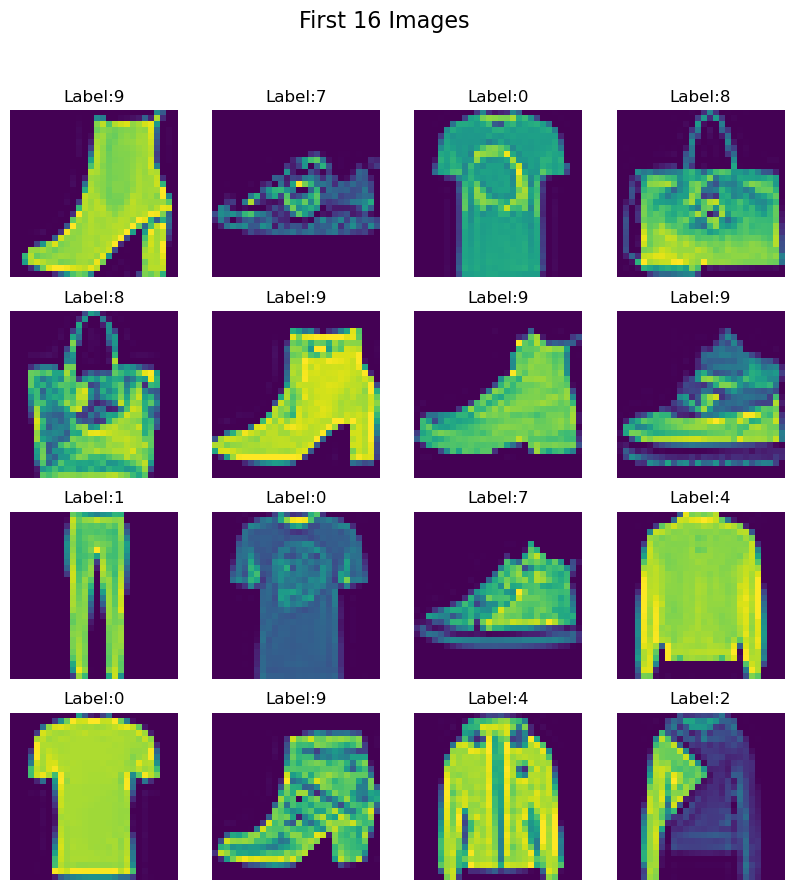

In [15]:
## create a 4X4 grid of images


fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images",fontsize=16)

for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img) ## display in grayscale
    ax.axis('off') ## remove axis for cleaner look
    ax.set_title(f"Label:{df.iloc[i,0]}") ## show the label
    

plt.show()

In [16]:
X=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [18]:
y

array([9, 7, 0, ..., 8, 4, 8], shape=(6000,))

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
## Scaling the features
X_train= X_train/255.0
X_test=X_test/255.0

In [26]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]], shape=(4800, 784))

In [31]:
## Create Customdataset class

class CustomDataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.features)
    
    def __getitem__(self,idx):
        return self.features[idx],self.labels[idx]



In [32]:
train_dataset=CustomDataset(X_train,y_train)
test_dataset=CustomDataset(X_test,y_test)

In [33]:
len(train_dataset)

4800

In [34]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [36]:
## create train and test dataloader

train_loader=DataLoader(train_dataset,shuffle=True,batch_size=32)
test_loader=DataLoader(test_dataset,shuffle=False,batch_size=32) ## we dont want to shuffle data during testing time

In [37]:
## define NN class


class ANN(nn.Module):
    def __init__(self,num_features):
            super().__init__()
            self.model=nn.Sequential(
                  nn.Linear(num_features,128),
                  nn.ReLU(),
                  nn.Linear(128,64),
                  nn.ReLU(),
                  nn.Linear(64,10)
                 ## nn.Softmax() you don't need to add softmax fn explicitally
                 ## in pytorch in Cross entropy loss, softmax is already implemented 

            )
    
    def forward(self,features):
          return self.model(features)





In [38]:
learning_rate=0.1
epochs=100

In [47]:
## instantiate the model

model=ANN(X_train.shape[1])

## loss_function
loss_function=nn.CrossEntropyLoss()

## optimizer

optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [50]:
## training loop


for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in train_loader:
        
        ## forward pass
        y_pred=model(batch_features)

        ## loss cal 
        loss=loss_function(y_pred,batch_labels)
         
        optimizer.zero_grad()
        ## back pass
        loss.backward()

        ## parameter update
        optimizer.step()

        total_epoch_loss=total_epoch_loss + loss.item()
    
    avg_epoch_loss = total_epoch_loss/len(train_loader)
    print(f"epoch:{epoch+1}, Loss: {avg_epoch_loss}")





epoch:1, Loss: 0.00031149725307235104
epoch:2, Loss: 0.00031095144146092935
epoch:3, Loss: 0.00030919267584977205
epoch:4, Loss: 0.00030429110488815544
epoch:5, Loss: 0.0003025429592768584
epoch:6, Loss: 0.00030000502891198267
epoch:7, Loss: 0.00029803380190666456
epoch:8, Loss: 0.0002968719154644835
epoch:9, Loss: 0.00029267028029911067
epoch:10, Loss: 0.0002903102098449987
epoch:11, Loss: 0.00028488673274599326
epoch:12, Loss: 0.0002847406194996438
epoch:13, Loss: 0.0002828923438240357
epoch:14, Loss: 0.00028104862899150856
epoch:15, Loss: 0.00027850939998946465
epoch:16, Loss: 0.0002765524615824688
epoch:17, Loss: 0.00027291282817410925
epoch:18, Loss: 0.0002719363402381229
epoch:19, Loss: 0.0002695117543286566
epoch:20, Loss: 0.0002659665160657217
epoch:21, Loss: 0.00026713205688186765
epoch:22, Loss: 0.00026435786134243244
epoch:23, Loss: 0.00025959845107233074
epoch:24, Loss: 0.0002596754574915394
epoch:25, Loss: 0.00025759224825378624
epoch:26, Loss: 0.0002535074106344837
epoch:

In [51]:
## set the model to evaluation mode
## tells the model we will use the model for evaluation purpose 
model.eval()


## why we need to explicitly tell model now you are in eval mode ?

ANN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

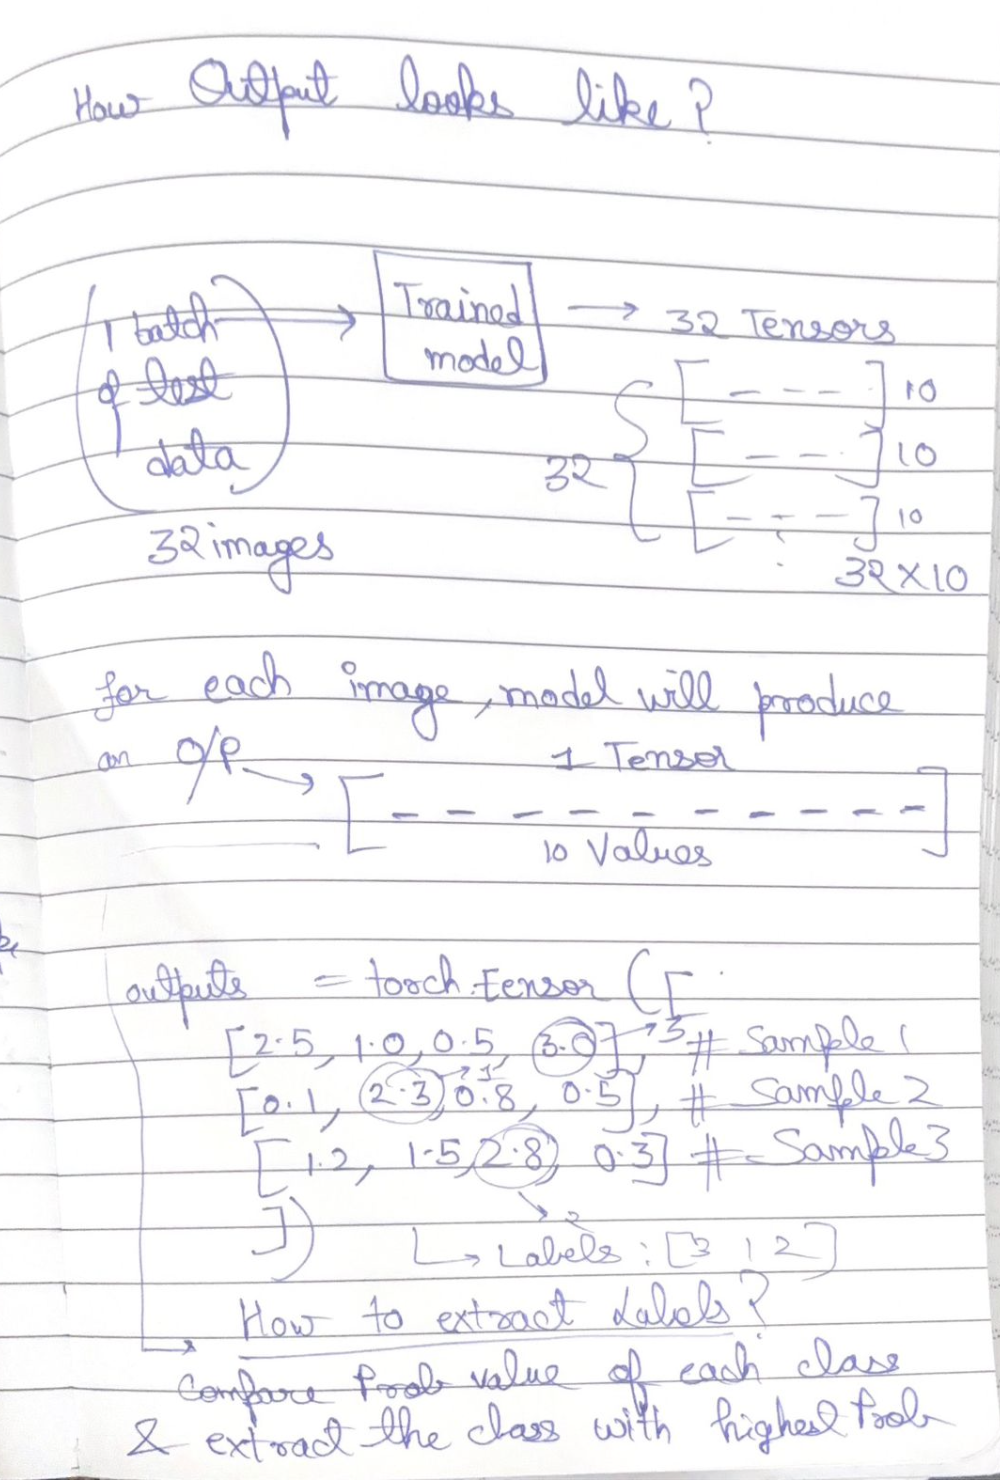

Apke evualtion mein khuch features alag tareeke se behave karte hai

example in training we do dropout but in eval we don't drop any neurons 

example 2 in batch norm we cal mean and std deviation of data but in prediction time we use the same mean and std deviation used in training 

In [56]:
## evaluation code


total=0
correct=0


with torch.no_grad():
    for batch_features,batch_labels in test_loader:
        outputs=model(batch_features)
        value,predicted_labels=torch.max(outputs,axis=1) ## gvies two tensors one is values and other gives indices
        print(predicted_labels)
        total=total+batch_labels.shape[0]
        correct=correct+ (predicted_labels==batch_labels).sum().item()
    print(correct/total)
        

tensor([7, 6, 5, 6, 3, 2, 5, 4, 9, 7, 0, 6, 4, 0, 5, 1, 7, 5, 6, 0, 4, 0, 2, 0,
        9, 6, 9, 3, 0, 1, 5, 6])
tensor([4, 8, 1, 6, 9, 3, 9, 6, 8, 5, 3, 1, 2, 3, 8, 9, 9, 9, 5, 0, 4, 0, 0, 4,
        1, 4, 8, 4, 2, 3, 0, 8])
tensor([0, 1, 4, 1, 4, 7, 6, 8, 2, 1, 8, 2, 3, 2, 4, 9, 1, 3, 7, 9, 4, 6, 4, 7,
        0, 4, 1, 3, 6, 1, 2, 6])
tensor([8, 3, 7, 1, 6, 5, 4, 2, 8, 7, 8, 5, 6, 5, 2, 4, 7, 9, 9, 7, 1, 6, 6, 6,
        1, 7, 1, 9, 7, 2, 0, 5])
tensor([6, 3, 5, 7, 9, 1, 9, 1, 5, 7, 1, 1, 5, 6, 1, 1, 9, 8, 0, 3, 3, 9, 8, 9,
        4, 4, 2, 6, 2, 2, 5, 2])
tensor([3, 4, 5, 4, 8, 4, 3, 8, 5, 9, 2, 8, 6, 4, 1, 5, 9, 9, 8, 5, 9, 6, 4, 5,
        0, 9, 1, 2, 4, 1, 4, 6])
tensor([6, 3, 6, 8, 1, 3, 3, 6, 2, 6, 1, 2, 7, 7, 0, 9, 1, 3, 6, 7, 9, 6, 2, 6,
        3, 3, 9, 7, 1, 9, 0, 3])
tensor([7, 1, 6, 9, 9, 0, 5, 1, 7, 0, 8, 2, 7, 6, 9, 3, 3, 7, 6, 2, 3, 5, 9, 4,
        4, 3, 4, 3, 1, 6, 2, 9])
tensor([4, 8, 0, 0, 3, 4, 1, 8, 0, 0, 0, 1, 1, 1, 6, 8, 0, 0, 1, 2, 5, 0, 6, 3,
        4, 3, 7,